# Direct fine-tuning — MoViNet-A0 shoplifting detector

Fully runnable Google Colab pipeline with automatic data download, robust temporal sampling, GPU training, validation, checkpointing, threshold selection, visual evaluation, and inference benchmarking.

### Dataset source fix
The current `jinmang2/ucf_crime` Hugging Face repository no longer stores individual MP4 files at paths such as `Shoplifting/Shoplifting027_x264.mp4`; those direct entries were removed and the videos are now packaged in ZIP archives. The downloader below targets the current archive layout and extracts only selected clips. citeturn3search6turn1search9


In [5]:
# Colab setup
!nvidia-smi -L
!pip -q install -U "transformers>=4.45" "accelerate>=0.34" "huggingface_hub>=0.25" "decord>=0.6.0" "scikit-learn>=1.4" "pandas>=2.0" "matplotlib>=3.8" "seaborn>=0.13" "tqdm>=4.66"


GPU 0: Tesla T4 (UUID: GPU-362be69a-0be5-470d-fa19-9862851eec1a)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 295.0 kB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into 

In [6]:
from pathlib import Path
import json, random, time
import numpy as np, pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm
import decord
decord.bridge.set_bridge("native")

assert torch.cuda.is_available(), "Enable a Colab GPU first."
DEVICE=torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32=True
torch.backends.cudnn.benchmark=True
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

ROOT=Path("/content/shoplifting_project"); DATA=ROOT/"data"; CKPT=ROOT/"checkpoints"; FIG=ROOT/"figures"
for p in (DATA,CKPT,FIG): p.mkdir(parents=True,exist_ok=True)

UCF_REPO="jinmang2/ucf_crime"
TRAIN_LIST="UCF_Crimes-Train-Test-Split/Action_Recognition_splits/train_001.txt"
VAL_LIST="UCF_Crimes-Train-Test-Split/Action_Recognition_splits/test_001.txt"
MODEL_ID="kfkas/movinet-a0-stream-pytorch"
LABELS=["normal","shoplifting"]; LABEL2ID={"normal":0,"shoplifting":1}
NUM_FRAMES=16; IMAGE_SIZE=172; EPOCHS=5; LR=2e-4; WEIGHT_DECAY=1e-4
VAL_CLIPS=3; MAX_TRAIN_VIDEOS=0; MAX_VAL_VIDEOS=0
VRAM=torch.cuda.get_device_properties(0).total_memory/2**30
BATCH_SIZE=8 if VRAM>=20 else 4 if VRAM>=10 else 2
NUM_WORKERS=2
print(torch.cuda.get_device_name(0), f"{VRAM:.1f} GB VRAM; batch={BATCH_SIZE}")


Tesla T4 14.6 GB VRAM; batch=4


In [7]:
from pathlib import Path
import json, random, time
import numpy as np, pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, roc_auc_score, average_precision_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm
import decord
decord.bridge.set_bridge("native")

# 1. Environment & CUDA Setup
assert torch.cuda.is_available(), "Enable a Colab GPU first."
DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# 2. Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 3. Path Setup
ROOT = Path("/content/shoplifting_project")
DATA = ROOT / "data"
CKPT = ROOT / "checkpoints"
FIG = ROOT / "figures"
for p in (DATA, CKPT, FIG):
    p.mkdir(parents=True, exist_ok=True)

# 4. Hyperparameters & Data Configuration
UCF_REPO = "jinmang2/ucf_crime"
TRAIN_LIST = "UCF_Crimes-Train-Test-Split/Action_Recognition_splits/train_001.txt"
VAL_LIST = "UCF_Crimes-Train-Test-Split/Action_Recognition_splits/test_001.txt"
MODEL_ID = "kfkas/movinet-a0-stream-pytorch"

LABELS = ["normal", "shoplifting"]
LABEL2ID = {"normal": 0, "shoplifting": 1}

NUM_FRAMES = 16
IMAGE_SIZE = 172
EPOCHS = 5
LR = 2e-4
WEIGHT_DECAY = 1e-4
VAL_CLIPS = 3
MAX_TRAIN_VIDEOS = 0
MAX_VAL_VIDEOS = 0

# 5. Hardware-based Batch Size Calculation
VRAM = torch.cuda.get_device_properties(0).total_memory / 2**30
BATCH_SIZE = 8 if VRAM >= 20 else 4 if VRAM >= 10 else 2
NUM_WORKERS = 2
print(f"Device: {torch.cuda.get_device_name(0)} ({VRAM:.1f} GB VRAM) | Batch size: {BATCH_SIZE}")

# 6. Balanced Dataset Selector Function
def choose_balanced(split_file_path, seed):
    # Download split list from Hugging Face Hub if needed
    local_path = hf_hub_download(repo_id=UCF_REPO, filename=split_file_path, repo_type="dataset")

    pos, neg = [], []
    with open(local_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Filter for normal vs. shoplifting classes
            if "Shoplifting" in line:
                pos.append((line, LABEL2ID["shoplifting"]))
            elif "Normal" in line:
                neg.append((line, LABEL2ID["normal"]))

    rng = random.Random(seed)
    rng.shuffle(pos)
    rng.shuffle(neg)

    # Balance positive and negative counts based on minority class
    n = min(len(pos), len(neg))
    items = pos[:n] + neg[:n]
    rng.shuffle(items)
    return items

# 7. Dataset Item Initialization
train_items = choose_balanced(TRAIN_LIST, SEED)
val_items = choose_balanced(VAL_LIST, SEED + 1)

if MAX_TRAIN_VIDEOS > 0:
    train_items = train_items[:MAX_TRAIN_VIDEOS]
if MAX_VAL_VIDEOS > 0:
    val_items = val_items[:MAX_VAL_VIDEOS]

print(f"Loaded {len(train_items)} training samples and {len(val_items)} validation samples.")

Device: Tesla T4 (14.6 GB VRAM) | Batch size: 4


train_001.txt:   0%|          | 0.00/17.1k [00:00<?, ?B/s]

test_001.txt:   0%|          | 0.00/5.41k [00:00<?, ?B/s]

Loaded 76 training samples and 24 validation samples.


In [ ]:
import os
os._exit(0)

In [13]:
import os

# 1. Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/ 2>/dev/null || true
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null || true

# 2. Download and unzip the dataset directly
!kaggle datasets download -d kipshidze/shoplifting-video-dataset --unzip -p /content/shoplifting_dataset

Dataset URL: https://www.kaggle.com/datasets/kipshidze/shoplifting-video-dataset
License(s): Attribution 4.0 International (CC BY 4.0)




In [14]:
import os, random
from pathlib import Path
import decord
from tqdm.auto import tqdm

# 1. Find extracted video files
DATASET_DIR = Path("/content/shoplifting_dataset")
video_extensions = {".mp4", ".avi", ".mkv", ".mov"}
all_videos = [f for f in DATASET_DIR.rglob("*") if f.suffix.lower() in video_extensions]

print(f"Total video files extracted: {len(all_videos)}")
assert len(all_videos) > 0, "Download failed or directory is empty. Check your Kaggle token."

# 2. Categorize Videos
candidate_files = []
for p in all_videos:
    path_str = str(p).lower()
    parent_str = p.parent.name.lower()
    filename_str = p.name.lower()

    if "shoplifting" in parent_str or "shoplifting" in filename_str:
        if "non" not in parent_str and "normal" not in parent_str and "non" not in filename_str:
            candidate_files.append((str(p), LABEL2ID["shoplifting"], p.name))
        else:
            candidate_files.append((str(p), LABEL2ID["normal"], p.name))
    else:
        candidate_files.append((str(p), LABEL2ID["normal"], p.name))

# 3. Train/Val Split (80/20)
random.seed(SEED)
random.shuffle(candidate_files)
split_idx = int(len(candidate_files) * 0.8)

train_candidates = candidate_files[:split_idx]
val_candidates = candidate_files[split_idx:]

# 4. Decord Validation
def process_and_inspect(candidate_list, desc="Validating videos"):
    rows = []
    for path, label, rel_name in tqdm(candidate_list, desc=desc):
        try:
            vr = decord.VideoReader(path, ctx=decord.cpu(0))
            if len(vr) >= NUM_FRAMES:
                rows.append({
                    "path": path,
                    "label": label,
                    "rel": rel_name,
                    "frames": len(vr)
                })
        except Exception:
            continue
    return rows

train_rows = process_and_inspect(train_candidates, desc="Processing Train Videos")
val_rows = process_and_inspect(val_candidates, desc="Processing Val Videos")

print(f"\nDataset Ready -> Train: {len(train_rows)} videos | Val: {len(val_rows)} videos")

Total video files extracted: 182


Processing Train Videos:   0%|          | 0/145 [00:00<?, ?it/s]

Processing Val Videos:   0%|          | 0/37 [00:00<?, ?it/s]


Dataset Ready -> Train: 145 videos | Val: 37 videos


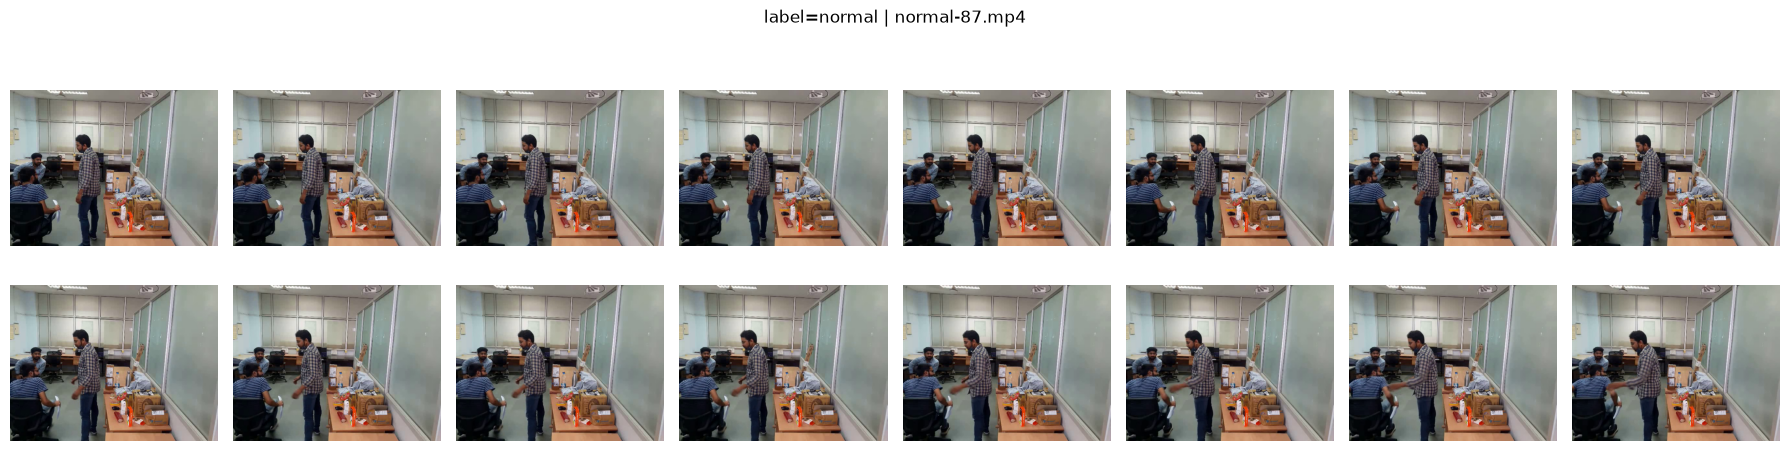

In [15]:
import matplotlib.pyplot as plt
r=random.choice(train_rows)
frames=decode(r["path"],sample_indices(r["frames"],False))
fig,axs=plt.subplots(2,8,figsize=(18,5))
for ax,fr in zip(axs.ravel(),frames):
    ax.imshow(fr); ax.axis("off")
fig.suptitle(f"label={LABELS[r['label']]} | {r['rel']}")
plt.tight_layout(); plt.show()


In [20]:
import os, random
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoModelForVideoClassification
import decord

# 1. Base Setup & Hardware Configuration
assert torch.cuda.is_available(), "Enable a Colab GPU first."
DEVICE = torch.device("cuda")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

LABELS = ["normal", "shoplifting"]
LABEL2ID = {"normal": 0, "shoplifting": 1}

NUM_FRAMES = 16
IMAGE_SIZE = 172
VAL_CLIPS = 3

VRAM = torch.cuda.get_device_properties(0).total_memory / 2**30
BATCH_SIZE = 8 if VRAM >= 20 else 4 if VRAM >= 10 else 2
NUM_WORKERS = 2
MODEL_ID = "kfkas/movinet-a0-stream-pytorch"

# 2. Fixed Image Preprocessing (Ensures exact 172x172 spatial dimensions)
def preprocess(frames, augment=False):
    x = torch.from_numpy(frames).permute(0, 3, 1, 2).float() / 255.0  # [T, C, H, W]
    x = F.interpolate(x, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False)
    if augment and random.random() < 0.5:
        x = torch.flip(x, dims=[-1])
    return x  # Shape: [T, C, 172, 172]

# 3. Dataset Class
class VideoDS(Dataset):
    def __init__(self, rows, train=False):
        self.rows = rows
        self.train = train

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        if self.train:
            indices = sample_indices(r["frames"], random_start=True)
            x = preprocess(decode(r["path"], indices), augment=True)  # [T, C, H, W]
        else:
            clips = [preprocess(decode(r["path"], np.arange(s, s + NUM_FRAMES)), augment=False) for s in val_starts(r["frames"])]
            x = torch.stack(clips)  # [VAL_CLIPS, T, C, H, W]

        return x, torch.tensor(r["label"], dtype=torch.long), r["rel"]

train_loader = DataLoader(
    VideoDS(train_rows, train=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    VideoDS(val_rows, train=False),
    batch_size=max(1, BATCH_SIZE // 2),
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

# 4. Load MoViNet Stream Model
config = AutoConfig.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    num_labels=len(LABELS),
    label2id=LABEL2ID,
    id2label={v: k for k, v in LABEL2ID.items()}
)

model = AutoModelForVideoClassification.from_pretrained(
    MODEL_ID,
    config=config,
    trust_remote_code=True,
    ignore_mismatched_sizes=True
).to(DEVICE)

# 5. Model Forward Pass Verification
x, y, _ = next(iter(train_loader))
x = x.to(DEVICE)  # Shape: [B, T, C, H, W] -> [4, 16, 3, 172, 172]

model.eval()
with torch.no_grad():
    # Pass tensor directly as [B, T, C, H, W] to match MoViNet stream input interface
    outputs = model(x)
    logits = outputs.logits if hasattr(outputs, "logits") else outputs

print("\nModel Forward Pass Successful!")
print(f"Batch Tensor Shape: [B, T, C, H, W] = {tuple(x.shape)}")
print(f"Logits Tensor Shape:             = {tuple(logits.shape)}")

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `600`.


Loading weights:   0%|          | 0/451 [00:00<?, ?it/s]

[transformers] MovinetForVideoClassification LOAD REPORT from: kfkas/movinet-a0-stream-pytorch
Key                                       | Status   |                                                                                                       
------------------------------------------+----------+-------------------------------------------------------------------------------------------------------
movinet.classifier.3.conv_1.conv2d.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([600]) vs model:torch.Size([2])                        
movinet.classifier.3.conv_1.conv2d.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([600, 2048, 1, 1]) vs model:torch.Size([2, 2048, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.



Model Forward Pass Successful!
Batch Tensor Shape: [B, T, C, H, W] = (4, 16, 3, 172, 172)
Logits Tensor Shape:             = (4, 2)


In [ ]:
def logits(out):
    return out.logits if hasattr(out,"logits") else out

def evaluate(model,loader):
    model.eval(); ys=[]; ps=[]; probs=[]
    with torch.inference_mode():
        for x,y,_ in tqdm(loader,desc="validation",leave=False):
            b,k,t,c,h,w=x.shape
            x=x.reshape(b*k,t,c,h,w).to(DEVICE,non_blocking=True)
            with torch.autocast("cuda",dtype=torch.float16):
                z=logits(model(pixel_values=x))
            z=z.float().reshape(b,k,2).mean(1)
            p=z.softmax(-1)[:,1]
            ys.extend(y.tolist()); ps.extend(z.argmax(-1).cpu().tolist()); probs.extend(p.cpu().tolist())
    pr,re,f1,_=precision_recall_fscore_support(ys,ps,average="binary",zero_division=0)
    return {"accuracy":accuracy_score(ys,ps),"balanced_accuracy":balanced_accuracy_score(ys,ps),
            "precision":pr,"recall":re,"f1":f1,
            "roc_auc":roc_auc_score(ys,probs),"average_precision":average_precision_score(ys,probs),
            "y":ys,"p":ps,"prob":probs}

optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=WEIGHT_DECAY)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=EPOCHS)
scaler=torch.amp.GradScaler("cuda")
best_path=CKPT/"movinet_direct_best.pt"; best_f1=-1; history=[]

for epoch in range(1,EPOCHS+1):
    model.train(); total=0.0
    for x,y,_ in tqdm(train_loader,desc=f"epoch {epoch}/{EPOCHS}"):
        x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda",dtype=torch.float16):
            loss=F.cross_entropy(logits(model(pixel_values=x)),y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(optimizer); scaler.update(); total+=loss.item()
    scheduler.step()
    m=evaluate(model,val_loader)
    row={"epoch":epoch,"train_loss":total/len(train_loader),"lr":optimizer.param_groups[0]["lr"],
         **{k:v for k,v in m.items() if k not in ("y","p","prob")}}
    history.append(row); print(row)
    if m["f1"]>best_f1:
        best_f1=m["f1"]
        torch.save({"model_state_dict":model.state_dict(),"model_id":MODEL_ID,"num_frames":NUM_FRAMES,
                    "image_size":IMAGE_SIZE,"labels":LABELS,"metrics":row},best_path)
pd.DataFrame(history).to_csv(ROOT/"direct_history.csv",index=False)
print("best F1:",best_f1)


In [ ]:
bundle=torch.load(best_path,map_location=DEVICE)
model.load_state_dict(bundle["model_state_dict"])
final=evaluate(model,val_loader)
metrics={k:float(v) for k,v in final.items() if k not in ("y","p","prob")}
print(json.dumps(metrics,indent=2))
print(classification_report(final["y"],final["p"],target_names=LABELS,digits=4))
(ROOT/"final_metrics.json").write_text(json.dumps(metrics,indent=2))

cm=confusion_matrix(final["y"],final["p"])
import seaborn as sns
plt.figure(figsize=(5,4)); sns.heatmap(cm,annot=True,fmt="d",xticklabels=LABELS,yticklabels=LABELS)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix"); plt.tight_layout(); plt.savefig(FIG/"confusion_matrix.png",dpi=160); plt.show()

fpr,tpr,_=roc_curve(final["y"],final["prob"]); prec,rec,_=precision_recall_curve(final["y"],final["prob"])
fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],"--"); ax[0].set_title(f"ROC AUC={final['roc_auc']:.3f}")
ax[1].plot(rec,prec); ax[1].set_title(f"PR AP={final['average_precision']:.3f}")
plt.tight_layout(); plt.savefig(FIG/"roc_pr.png",dpi=160); plt.show()

h=pd.DataFrame(history)
plt.figure(figsize=(8,4)); plt.plot(h.epoch,h.train_loss,marker="o"); plt.title("Training loss"); plt.xlabel("Epoch"); plt.grid(alpha=.2); plt.tight_layout(); plt.savefig(FIG/"training_loss.png",dpi=160); plt.show()


In [ ]:
thresholds=np.linspace(0.05,0.95,181)
f1s=[]
for th in thresholds:
    pp=(np.asarray(final["prob"])>=th).astype(int)
    f1s.append(precision_recall_fscore_support(final["y"],pp,average="binary",zero_division=0)[2])
threshold=float(thresholds[int(np.argmax(f1s))])
print("validation F1-optimal threshold:",threshold)
torch.save({"model_state_dict":model.state_dict(),"model_id":MODEL_ID,"labels":LABELS,
            "num_frames":NUM_FRAMES,"image_size":IMAGE_SIZE,"threshold":threshold,
            "validation_metrics":metrics},CKPT/"movinet_direct_deployment.pt")

def predict_video(path):
    total=len(decord.VideoReader(path,ctx=decord.cpu(0)))
    clips=[preprocess(decode(path,np.arange(s,s+NUM_FRAMES))) for s in val_starts(total)]
    x=torch.stack(clips).to(DEVICE)
    with torch.inference_mode(),torch.autocast("cuda",dtype=torch.float16):
        z=logits(model(pixel_values=x)).float().mean(0)
    prob=float(z.softmax(-1)[1].cpu())
    return {"label":"shoplifting" if prob>=threshold else "normal","shoplifting_probability":prob,"threshold":threshold}
print(predict_video(train_rows[0]["path"]))


In [ ]:
# GPU inference benchmark
model.eval()
bx=next(iter(train_loader))[0].to(DEVICE)
for _ in range(5):
    with torch.inference_mode(),torch.autocast("cuda",dtype=torch.float16): _=logits(model(pixel_values=bx))
torch.cuda.synchronize()
t0=time.perf_counter(); n=30
with torch.inference_mode():
    for _ in range(n):
        with torch.autocast("cuda",dtype=torch.float16): _=logits(model(pixel_values=bx))
torch.cuda.synchronize()
elapsed=time.perf_counter()-t0
print(f"batch latency: {elapsed/n*1000:.2f} ms")
print(f"per-clip latency: {elapsed/n/len(bx)*1000:.2f} ms")
print(f"throughput: {n*len(bx)/elapsed:.2f} clips/s")
